# LayoutParser

A Python library for Document Image Analysis (DIA)

> Use Pillow version < 10.0 when working with Detectron2.
#### References:

- Official Notebook: [Examples from Layout Parser on GitHub](https://github.com/Layout-Parser/layout-parser/blob/master/examples/OCR%20Tables%20and%20Parse%20the%20Output.ipynb)

- GitHub Repository: [Layout-Parser/layout-parser](https://github.com/Layout-Parser/layout-parser)

- Official Documentation: [Detectron2 Documentation](https://detectron2.readthedocs.io/en/latest/tutorials/install.html)

- Research Paper: [LayoutParser: A Unified Toolkit for Deep Learning-Based Document Image Analysis](https://arxiv.org/abs/2103.15348)

- Dataset: [A Large Dataset of Historical Japanese Documents with Complex Layouts](https://arxiv.org/abs/2004.08686)

- [Layout Parser Sharing Platform for pretraiened model](https://layout-parser.github.io/platform/)


### Install Dependencies
Install the LayoutParser library from the PyPi package, the Tesseract OCR engine, and other required dependencies.

In [1]:
%%bash
pip install Pillow==9.5.0 -q
pip install -U layoutparser -q
pip install 'git+https://github.com/facebookresearch/detectron2.git' -q
pip install layoutparser[ocr] -q

sudo apt-get update > /dev/null 2>&1
sudo apt-get install -y -q tesseract-ocr > /dev/null 2>&1
sudo apt-get install -y -q libtesseract-dev > /dev/null 2>&1

### Import the libraries

In [2]:
import cv2
import layoutparser as lp

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
from tqdm.notebook import tqdm
%matplotlib inline

### Download the model
https://www.dropbox.com/s/6icw6at8m28a2ho/model_final.pth?dl=1

In [3]:
!wget https://www.dropbox.com/s/6icw6at8m28a2ho/model_final.pth?dl=1 -qO model_final.pth

#### Download the Sample Image

In [4]:
!wget -q  https://raw.githubusercontent.com/Layout-Parser/layout-parser/refs/heads/main/examples/data/paper-image.jpg

### Read an image from the source files to infer on it

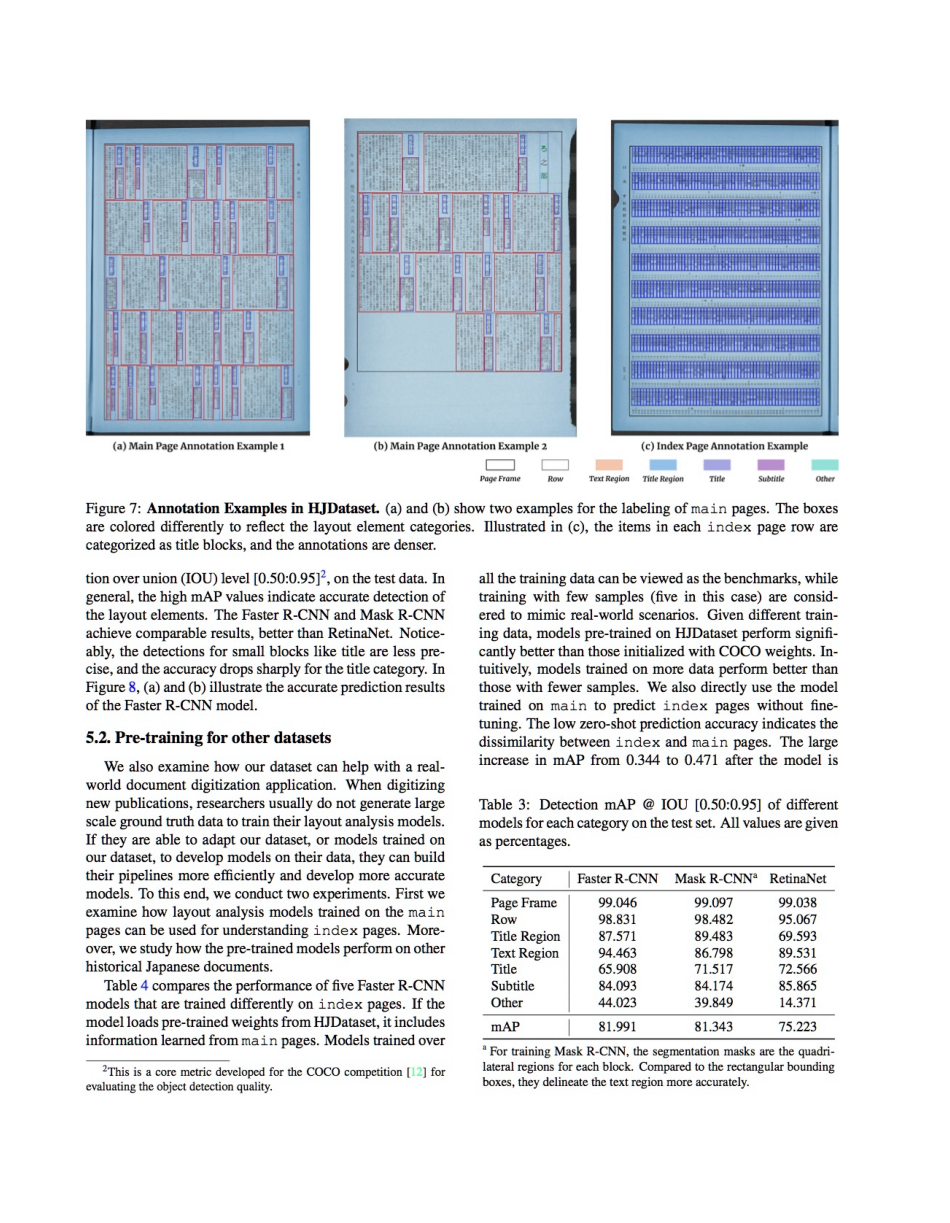

In [5]:
image = cv2.imread('paper-image.jpg')
# display image
plt.figure(figsize=(12,16))
plt.imshow(image)
plt.axis('off')
plt.show()

### Loading the Layout Detection Model  

Layout Parser provides many pretrained models.  
**Check out the [Layout Parser Sharing Platform](https://layout-parser.github.io/platform/)** for available models.  

#### ⚠️ Error Note:  
```bash
> detect_model = lp.AutoLayoutModel("lp://detectron2/PrimaLayout/mask_rcnn_R_50_FPN_3x")
AssertionError: Checkpoint /root/.torch/iopath_cache/s/h7th27jfv19rxiy/model_final.pth not found!
```  
This issue commonly occurs on Linux distributions when downloading the model.  

#### ✅ Solution:  
Manually download the model and specify its path. You can find download links for different models config in the [ModelZoo documentation of LayoutParser](https://github.com/Layout-Parser/layout-parser/blob/f230971f7695229ace0c2d68039e466b036101de/docs/notes/modelzoo.md) and the model path used in [this line of code in layout parser code](https://github.com/Layout-Parser/layout-parser/blob/f230971f7695229ace0c2d68039e466b036101de/src/layoutparser/models/detectron2/catalog.py#L19-L24)

For further discussion, refer to this GitHub thread: [GitHub Discussion](https://github.com/Layout-Parser/layout-parser/issues/168#issuecomment-1386287410).

In [6]:
import os
import requests

BASE_DIR = os.path.join(os.path.expanduser("~"), ".layout-parser-models")
MODEL_NAME = "model_final.pth"

# Define model download URL
MODEL_URL = "https://www.dropbox.com/s/dgy9c10wykk4lq4/model_final.pth?dl=1"
CONFIG_FILE_URL = "https://www.dropbox.com/s/dgy9c10wykk4lq4/config.yaml?dl=1"

def downlaod_model(url: str, save_path: str):
    """Download the model file from the given URL and save it to the specified path."""
    try:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        print(f"Downloading model from {url}....")
        response = requests.get(url, stream=True)
        response.raise_for_status()

        # Get the total file size from headers
        total_size = int(response.headers.get("content-length", 0))

        # Save the model file
        with open(save_path, "wb") as fp, tqdm(
            desc="Downloading",
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
        ) as bar:
            for chunk in response.iter_content(chunk_size=8192):
                fp.write(chunk)
                bar.update(len(chunk))

        print(f"Model dowloaded sucessfully and saved to {save_path}")
    except requests.exceptions.RequestException as err:
        print(f"Error downloading the model: {err}")


config_save_path = "models/config.yaml"
model_path = "models/model_final.pth"
downlaod_model(MODEL_URL, model_path)

Downloading:   0%|          | 0.00/315M [00:00<?, ?B/s]

Model dowloaded sucessfully and saved to models/model_final.pth


In [7]:
model = lp.AutoLayoutModel("lp://detectron2/PubLayNet/faster_rcnn_R_50_FPN_3x/config",
                                  model_path=model_path,
                                  extra_config=["MODEL.ROI_HEADS.SCORE_THRESH_TEST", 0.8],
                                  label_map={0: "Text", 1: "Title", 2: "List", 3: "Table", 4: "Figure"})

### Detect Locations of Words from the Sample Image


| **Column Name** | **Description** |
|-----------------|-----------------|
| **($x_1$, $y_1$)**  | Coordinates of the top-left corner of the bounding box. |
| **($x_2$, $y_2$)**  | Coordinates of the bottom-right corner of the bounding box. |
| **block_type**  | Type of layout element (rectangle for all detected elements). |
| **type**        | An integer indicating the type/category of the detected element (likely specific to the dataset/model used). |
| **score**       | Confidence score of the detection. |


In [8]:
layout = model.detect(image)

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [9]:
df_data = layout.to_dataframe()
df_data.head()

,x_1,y_1,x_2,y_2,block_type,type,score
0,648.992249,1418.711304,1132.680542,1479.303955,rectangle,Text,0.999598
1,106.124619,1032.074707,599.297791,1323.208984,rectangle,Text,0.998180
2,639.547363,773.126587,1135.976562,1044.650757,rectangle,Text,0.997486
3,104.368591,767.328186,595.175964,970.451050,rectangle,Text,0.997432
4,107.376183,1448.544189,598.399841,1488.016113,rectangle,Text,0.995352


In [10]:
print(">> Shape of detected words: ", df_data.shape)
print(">> Types of block:          ", df_data["block_type"].unique())
print(">> Types of word:           ", df_data["type"].unique())

>> Shape of detected words:  (13, 7)
>> Types of block:           ['rectangle']
>> Types of word:            ['Text' 'Figure' 'Title' 'Table']


#### Plot of word detection Confidence

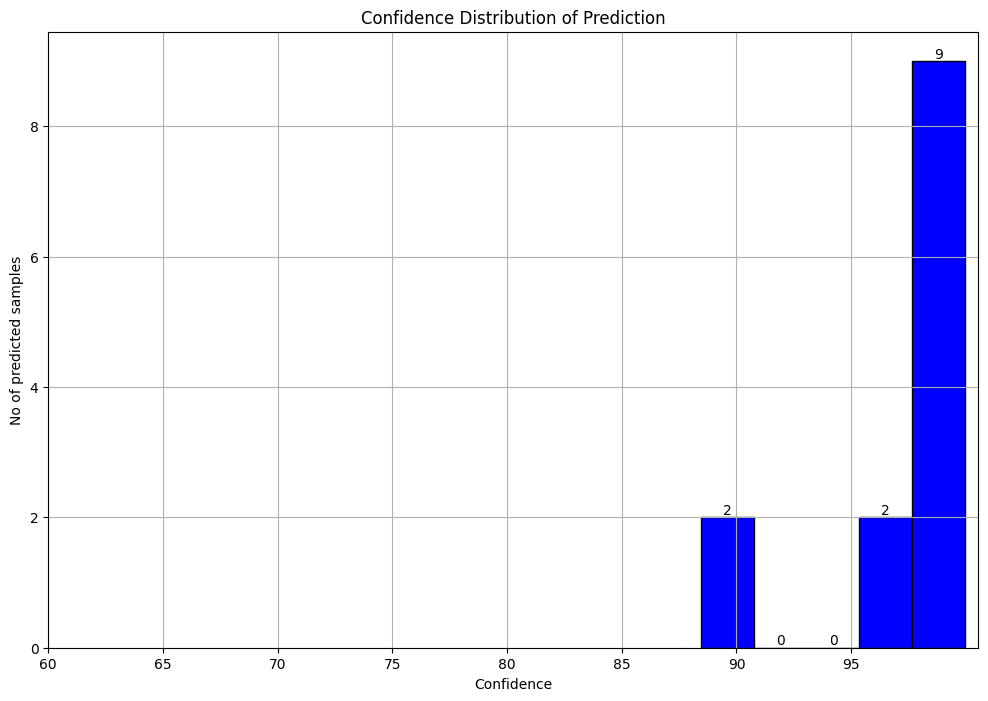

In [11]:
plt.figure(figsize=(12,8))
# Plot histogram
n, bins, patches = plt.hist(df_data['score']*100, bins=5, color='blue', edgecolor='black')

# Add text annotations for frequencies
for i in range(len(n)):
    plt.text(bins[i] + (bins[i + 1] - bins[i]) / 2, n[i], int(n[i]), ha='center', va='bottom')

plt.ylabel("No of predicted samples")
plt.xticks(range(60, 100, 5))
plt.title('Confidence Distribution of Prediction')
plt.xlabel('Confidence')

plt.grid()
plt.show()

In [12]:
cpy_image = image.copy()

for record in range(len(df_data)):
    # Draw a rectangle on the image
    cpy_image = cv2.rectangle(
        cpy_image,
        (int(df_data.iloc[record]["x_1"]), int(df_data.iloc[record]["y_1"])),
        (int(df_data.iloc[record]["x_2"]), int(df_data.iloc[record]["y_2"])),
        (255, 0, 0),
        1
    )


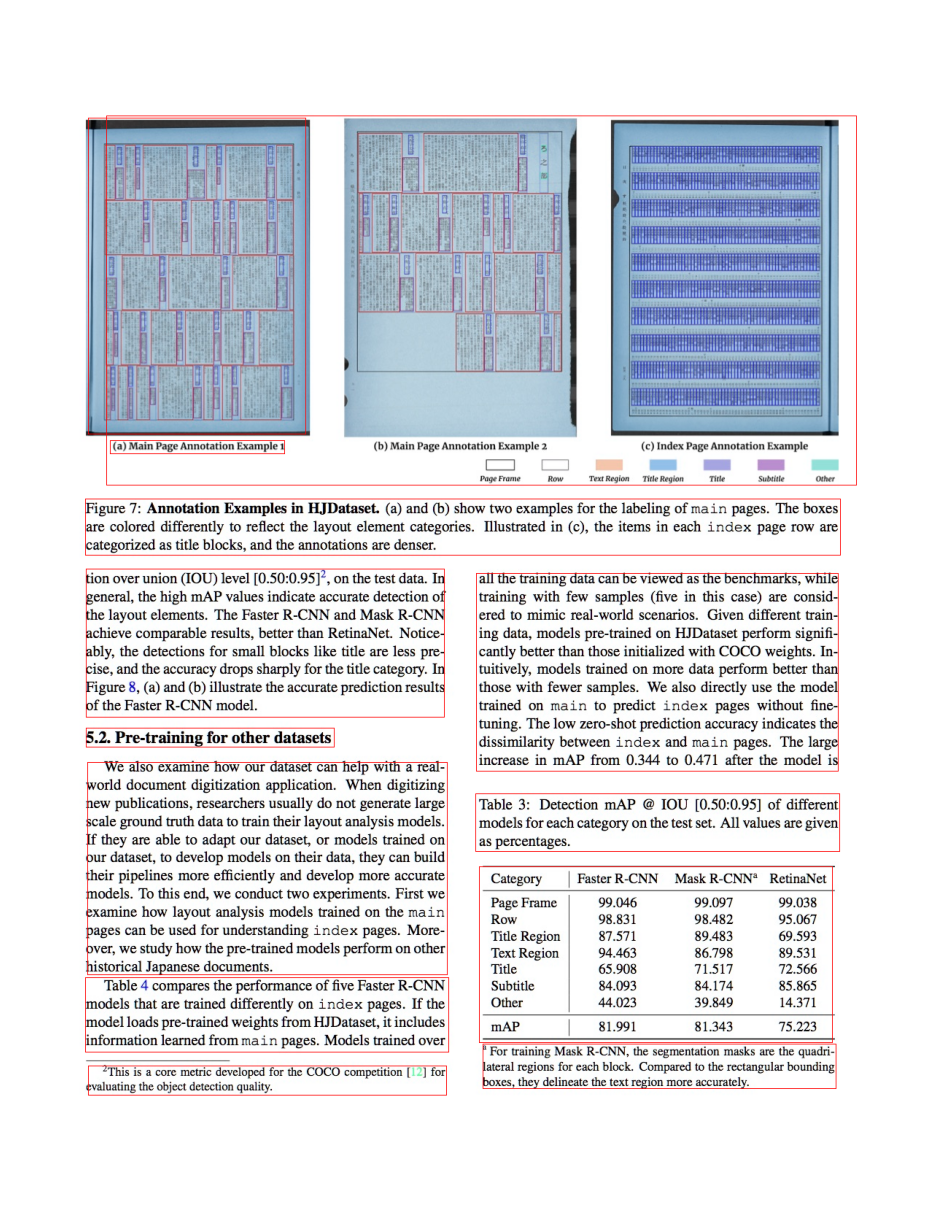

In [13]:
# display image
plt.figure(figsize=(12,16))
plt.imshow(cpy_image)
plt.axis('off')
plt.show()

### Use the co-ordination system to process the detected Layout
- [Information about layout - Layout parser Documentation](https://layout-parser.readthedocs.io/en/latest/api_doc/elements.html#layoutparser.elements.TextBlock)

In [14]:
layout[0]

TextBlock(block=Rectangle(x_1=648.9922485351562, y_1=1418.7113037109375, x_2=1132.6805419921875, y_2=1479.303955078125), text=None, id=None, type=Text, parent=None, next=None, score=0.9995978474617004)

In [15]:
text_blocks = lp.Layout([b for b in layout if b.type=='Text'])
figure_blocks = lp.Layout([b for b in layout if b.type=='Figure'])

print(f">> Number of TEXT blocks: {len(text_blocks)}")
print(f">> Number of FIGURE blocks: {len(figure_blocks)}")

>> Number of TEXT blocks: 9
>> Number of FIGURE blocks: 2


**Do OCR in text region**
We need only text block to OCR.

In [16]:
# Sort the text regions detected insisde the figure region
h, w = image.shape[:2]

left_interval = lp.Interval(0, w/2, axis='x').put_on_canvas(image)

left_blocks = text_blocks.filter_by(left_interval, center=True)
left_blocks.sort(key=lambda b: b.coordinates[1], inplace=True)

right_blocks = text_blocks.filter_by(lp.Interval(w/2, w, axis='x'), center=True)
right_blocks.sort(key=lambda b: b.coordinates[1], inplace=True)

# Combine two lists and add the index
text_blocks = lp.Layout([b.set(id = idx) for idx, b in enumerate(left_blocks + right_blocks)])

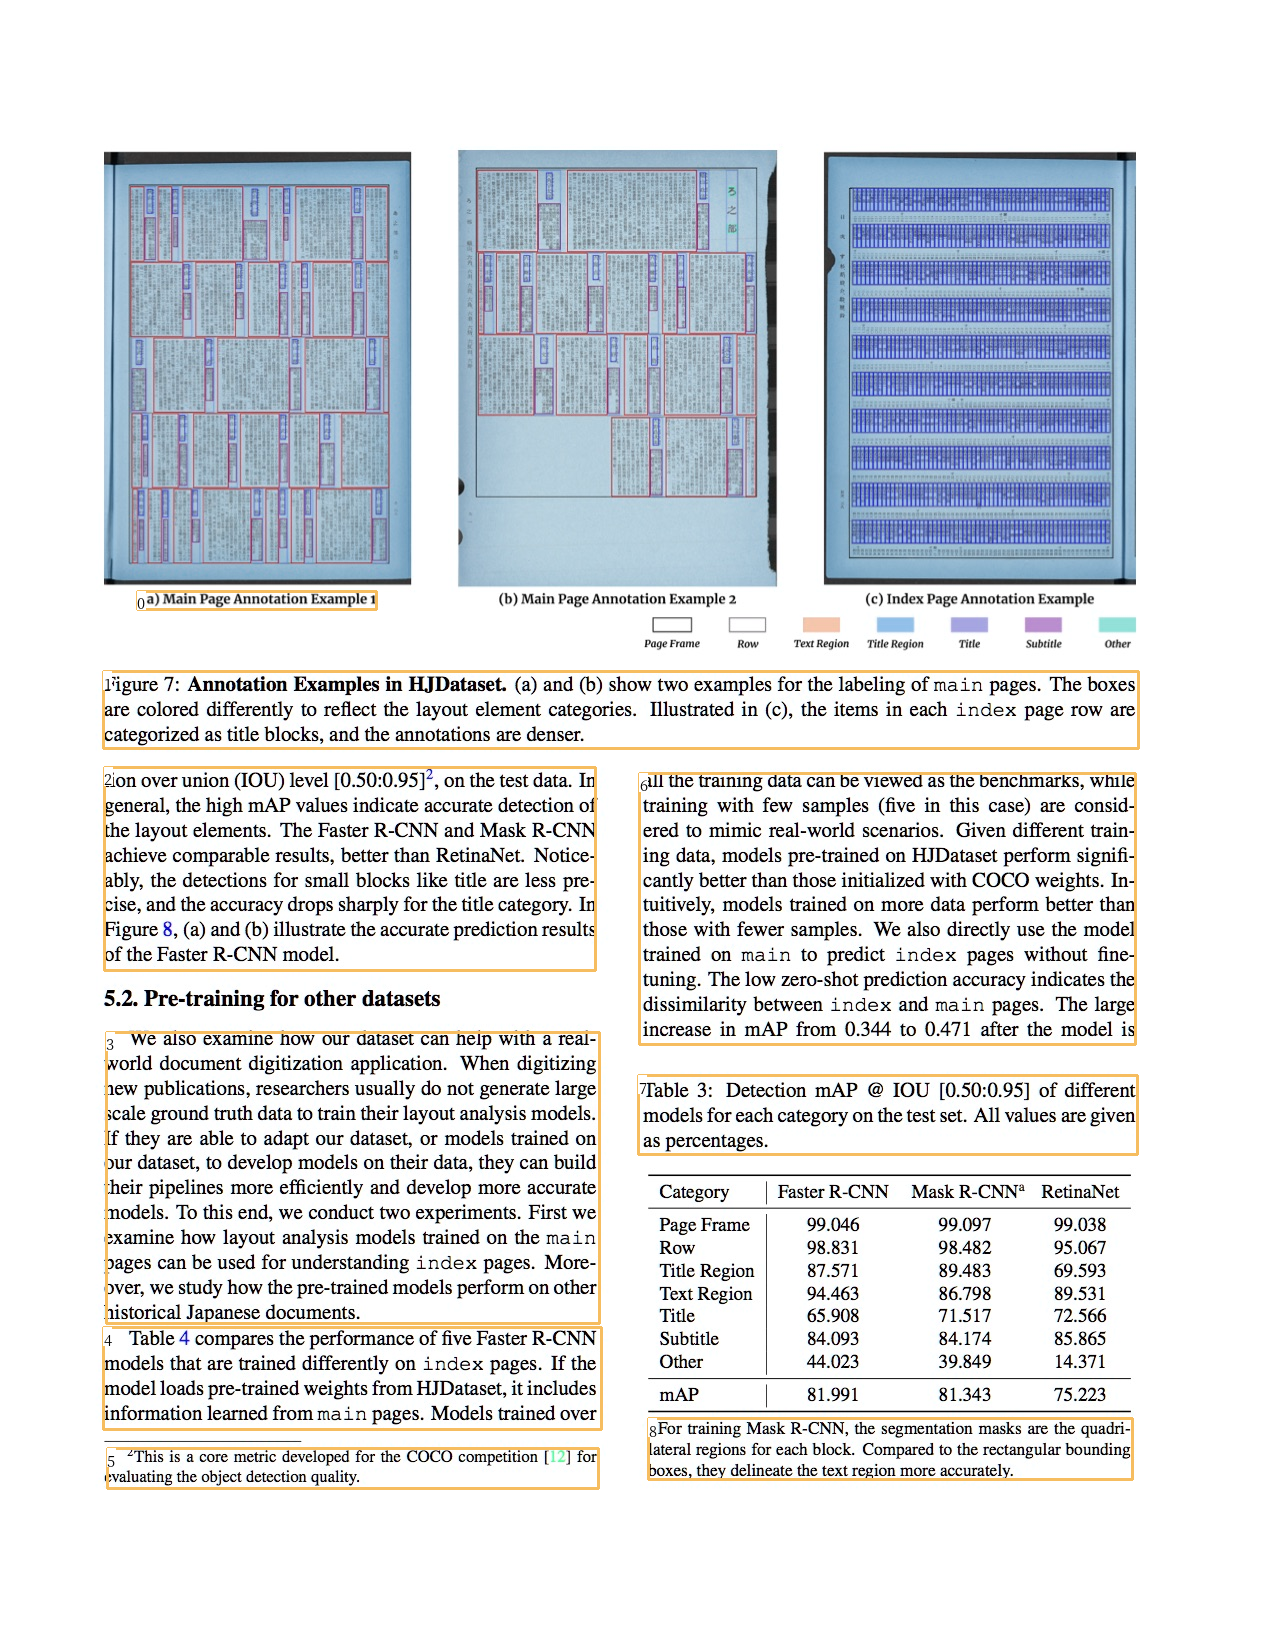

In [17]:
# Visualiza the cleaned text blocks
lp.draw_box(image, text_blocks, box_width=3, show_element_id=True)

### OCR Functionality in `layoutparser`

You can install OCR component in layoutparser
```bash
pip install layoutparser[ocr]
```

In [18]:
ocr_agent = lp.TesseractAgent(languages="eng")

for block in tqdm(text_blocks):
    segment_image = (block.pad(left=5, right=5, bottom=5)
                           .crop_image(image))
    ocr_result = ocr_agent.detect(segment_image)
    block.set(text=ocr_result, inplace=True)

  0%|          | 0/9 [00:00<?, ?it/s]

In [20]:
for text in text_blocks.get_texts():
    print(text, end="\n-----\n")

(a) Main Page Annotation Example 1

-----
Figure 7: Annotation Examples in HJDataset. (a) and (b) show two examples for the labeling of main pages. The boxes
are colored differently to reflect the layout element categories. Illustrated in (c), the items in each index page row are
categorized as title blocks, and the annotations are denser.

-----
tion over union (IOU) level [0.50:0.95]’, on the test data. In
general, the high mAP values indicate accurate detection of
the layout elements. The Faster R-CNN and Mask R-CNN
achieve comparable results, better than RetinaNet. Notice-
ably, the detections for small blocks like title are less pre-
cise, and the accuracy drops sharply for the title category. In
Figure 8, (a) and (b) illustrate the accurate prediction results
of the Faster R-CNN model.

-----
‘We also examine now our Gataset can help with a real-
world document digitization application. When digitizing
new publications, researchers usually do not generate large
scale ground tr